In [1]:
## Assuming Distribution is Gaussian for each class
## And finding MLE best fit Gaussian for each class (uk(mean) accross features for class kth class , covariance matrix for the kth class data )
## for new Sample x -> probability of x belong to that class

In [2]:
import pandas  as pd
import numpy as np

In [3]:


housing_data = pd.read_csv('/workspaces/FROM_SCRATCH_ML/datasets/IRIS.csv')

In [4]:
housing_data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
## spitting into 80-20 
from sklearn.model_selection import train_test_split
train_df, test_df =train_test_split(housing_data, test_size=0.2,stratify=housing_data['species'],random_state= 42)

In [6]:
train_df['species'].unique().tolist()

['Iris-setosa', 'Iris-virginica', 'Iris-versicolor']

In [7]:
label = 'Iris-versicolor'

In [ ]:
df_iris_setosa = train_df[train_df['species'] ==label].reset_index(drop =True)

## droping species column
u_iris_setosa = df_iris_setosa.drop(columns = ['species'])

## numpy  
u_iris_setosa = u_iris_setosa.values

## taking mean
u_iris_setosa  = np.mean(u_iris_setosa, axis = 0)
u_iris_setosa = u_iris_setosa.reshape(1,-1)


## Covariance_matrix  just by using numpy
##(x-u)@(x-u).T
X_iris_setos = df_iris_setosa.drop(columns = ['species']).values
cov_iris_setosa = (X_iris_setos - u_iris_setosa).T@(X_iris_setos - u_iris_setosa)/(len(df_iris_setosa))
pie_iris_setosa= train_df['species'].value_counts()['Iris-setosa']/train_df['species'].value_counts().sum()


### Bayes theorem
![Screenshot from 2026-04-02 12-54-36.png](<attachment:Screenshot from 2026-04-02 12-54-36.png>)

### Multivariate Normal Distribution
![Screenshot from 2026-04-02 12-57-57.png](<attachment:Screenshot from 2026-04-02 12-57-57.png>)

### Prediction time
![Screenshot from 2026-04-02 13-01-24.png](<attachment:Screenshot from 2026-04-02 13-01-24.png>)

### taking log to avoid underlow (very small values not go to Zero)
![Screenshot from 2026-04-02 13-03-13.png](<attachment:Screenshot from 2026-04-02 13-03-13.png>)
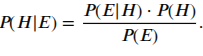
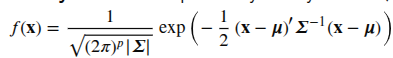
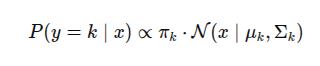
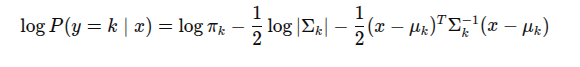

In [9]:
## taking sample from text df 
sample_point = test_df.sample(1, random_state=42)

In [10]:
y_test = sample_point['species']

In [11]:
y_test

18    Iris-setosa
Name: species, dtype: str

In [12]:
x_test = sample_point.drop(columns =['species']).values

In [13]:
x_test.shape

(1, 4)

In [14]:
pie = np.round(pie_iris_setosa,2).item()

In [15]:
## prior probability of  class iris-setosa
first_term = np.log(pie)

In [16]:
## second term is 0.5*determinant(covariance matrix)
second_term = 0.5*np.log(np.linalg.det(cov_iris_setosa))

In [17]:
## x-u, cov inverse, (x-u).T
x_minus_u = x_test-u_iris_setosa
inverse_of_cov = np.linalg.inv(cov_iris_setosa)
x_minus_u_transpose = x_minus_u.T

third_term = 0.5*(x_minus_u@inverse_of_cov@x_minus_u_transpose)

In [18]:
value_versicolor = first_term - second_term -third_term

In [19]:
first_term,second_term,third_term

(np.float64(-1.1086626245216111),
 np.float64(-5.438554519819839),
 array([[57.81383268]]))

In [20]:
value_versicolor

array([[-53.48394079]])

In [22]:
# value_setosa, value_verginica, value_versicolor

In [23]:
np.e**value_versicolor[0]

array([5.91860893e-24])

In [ ]:
## third term



In [52]:
## at the time of prediction  from bayes rule
## 
## p([y=k]/x) = p(x/[y=k])*p(y=k)/p(x)
## Here p(x) will be common for class so for comparision we don't want this shit


In [67]:
train_df['species'].value_counts()['Iris-setosa']/train_df['species'].value_counts().sum()

np.float64(0.3333333333333333)

In [60]:
u_iris_setosa

array([[4.985 , 3.4025, 1.48  , 0.2525]])

In [61]:
cov_iris_setosa

array([[0.092775  , 0.0940375 , 0.0092    , 0.0122875 ],
       [0.0940375 , 0.15674375, 0.0153    , 0.01386875],
       [0.0092    , 0.0153    , 0.0251    , 0.00555   ],
       [0.0122875 , 0.01386875, 0.00555   , 0.01349375]])

In [49]:
u_iris_setosa


array([4.985 , 3.4025, 1.48  , 0.2525])

In [51]:
u_iris_setosa.shape

(1, 4)

NameError: name 'x' is not defined

sepal_length    4.9850
sepal_width     3.4025
petal_length    1.4800
petal_width     0.2525
dtype: float64

In [ ]:
u_iris_setosa = np.mean(u_iris_setosa, axis = 0)

u_iris_setosa

In [53]:
train_df['species'].unique()

<StringArray>
['Iris-setosa', 'Iris-virginica', 'Iris-versicolor']
Length: 3, dtype: str

In [30]:
## creating function to generate model parameteters by class

def generate_parameters_of_distribution(df:pd.DataFrame, label_name :str):
    pie= df['species'].value_counts()[label_name]/df['species'].value_counts().sum()
    
    df = df[df['species'] ==label].reset_index(drop =True)

    ## droping species column
    u = df.drop(columns = ['species'])

    ## numpy  
    u = u.values

    ## taking mean
    u  = np.mean(u, axis = 0)
    u = u.reshape(1,-1)


    ## Covariance_matrix  just by using numpy
    ##(x-u)@(x-u).T
    x = df_iris_setosa.drop(columns = ['species']).values
    cov = (x - u).T@(x - u)/(len(df))


    return u, cov, pie # prior probability


In [31]:
parameters = {}

labels = train_df['species'].unique().tolist()
## initializing parameters
for label in labels:
    parameters[label] = []

for label in labels:
    u, cov, pie= generate_parameters_of_distribution(train_df, label)
    parameters[label].append(u); parameters[label].append(cov); parameters[label].append(pie); 


In [33]:
parameters

{'Iris-setosa': [array([[4.985 , 3.4025, 1.48  , 0.2525]]),
  array([[ 1.114625  , -0.5528625 ,  2.7661875 ,  1.0486875 ],
         [-0.5528625 ,  0.51875625, -1.74793125, -0.66379375],
         [ 2.7661875 , -1.74793125,  7.87825   ,  3.01859375],
         [ 1.0486875 , -0.66379375,  3.01859375,  1.17365625]]),
  np.float64(0.3333333333333333)],
 'Iris-virginica': [array([[6.61, 2.98, 5.58, 2.04]]),
  array([[0.684   , 0.22015 , 1.048875, 0.5295  ],
         [0.22015 , 0.1459  , 0.36645 , 0.19835 ],
         [1.048875, 0.36645 , 1.95375 , 1.01475 ],
         [0.5295  , 0.19835 , 1.01475 , 0.5525  ]]),
  np.float64(0.3333333333333333)],
 'Iris-versicolor': [array([[5.93  , 2.75  , 4.2525, 1.32  ]]),
  array([[0.2216    , 0.06375   , 0.146175  , 0.0399    ],
         [0.06375   , 0.093     , 0.061125  , 0.03275   ],
         [0.146175  , 0.061125  , 0.19149375, 0.05895   ],
         [0.0399    , 0.03275   , 0.05895   , 0.0341    ]]),
  np.float64(0.3333333333333333)]}

In [ ]:
def predict_sample(parameters, data_point):
    pass


SyntaxError: expected ':' (3687381634.py, line 1)